In [1]:
from _src.Utils.CompositionLoader import CompositionExcelLoader
from _src.Composition.CompositionV2 import Composition
from _src.PhaseStability.TwoPhaseStabilityTestV3 import TwoPhaseStabilityTest
from _src.VLE.PhaseEquilibriumNewtonV2 import PhaseEquilibriumNewton
from _src.Utils.FluidPropertiesCalculatorV2 import FluidPropertiesCalculator
from _src.EOS.BaseEOS import EOSType

## Загрузка состава из БД

In [2]:
composition_db = Composition.from_db(r'C:\Users\user\Desktop\PVTcalc\models.json')

In [3]:
comp_KRSNL = composition_db.KRSNL_PVTSIM

In [4]:
comp_KRSNL.normalize_composition()

In [5]:
list(comp_KRSNL.composition_data['b'].values())

[2.4036014744301757,
 2.6647238394146395,
 2.678640457356527,
 4.042696857798534,
 5.630209200955264,
 7.2318678657829105,
 7.239220484017923,
 8.782207061403382,
 9.008205779814855,
 10.569725128221672,
 11.12752056772811,
 12.505473975552476,
 14.130823038987433,
 15.883554544951771,
 17.66685442808586,
 19.53985072003438,
 21.250824822345646,
 23.09329999635536,
 25.170073818659002,
 27.213679915152603,
 29.286308002554648,
 31.057862587840575,
 32.72540714548372,
 34.656199714480834,
 36.67622635664682,
 38.57287705362734,
 40.54526820865336,
 42.50775576964399,
 44.704421313632025,
 46.8345446184484,
 49.04874740487831,
 51.25521910259816,
 53.2570782831901,
 55.02541007934495,
 56.94152869144317,
 58.81073658595427,
 60.73180764241405,
 62.604212623866054,
 64.63210113675625,
 66.61206437013463]

In [6]:
comp_PRRZLM = composition_db.PRRZLM_MDT_TEST


## Старая загрузка составов

In [7]:
xl_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\prrzlm_mdt.xlsx')
comp_dict = xl_loader.load(header=True, sheet = 'to_model')

In [8]:
composition = Composition(comp_dict, eos_name= EOSType.PREOS)
composition.evaluate_composition_data({'critical_temperature': 'kesler lee',
                                                    'critical_pressure': 'kesler lee',
                                                    'acentric_factor': 'riazi al sahhaf',
                                                    'critical_volume': 'hall yarborough',
                                                    'Kw': 'k watson',
                                                    'shift_parameter': 'jhaveri youngren'})

composition.edit_component_properties('C36', 'molar_mass', 650)

In [ ]:
composition2 = Composition(comp_dict)
composition2.evaluate_composition_data({'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'pedersen',
                                                    'acentric_factor': 'riazi al sahhaf',
                                                    'critical_volume': 'hall yarborough',
                                                    'Kw': 'k watson',
                                                    'shift_parameter': 'jhaveri youngren'})

In [ ]:
composition2.normalize_composition()

In [ ]:
composition.composition_data.keys()

In [ ]:
for i in composition.composition_data['acentric_factor'].values():
    print(i)

## Расчет флеша

In [9]:
from _src.VLE.Flash import Flash
from _src.Utils.Conditions import Conditions

In [115]:
conds_stable = Conditions(200, 250)
conds_unstable = Conditions(151, 110)

In [116]:
comp_KRSNL.T = conds_stable.t

In [117]:
flash_obj1 = Flash(comp_KRSNL, conds_stable)

In [118]:
flash_res1 = flash_obj1.calculate()

In [119]:
flash_res1

FlashResult(pressure=200, temperature=523.14, vapor=PhaseState(mole_fraction=0.15434774280173963, composition={'N2': 0.0056777804604257595, 'CO2': 0.018640138130388284, 'C1': 0.5871931707806527, 'C2': 0.12838345722683742, 'C3': 0.08476296486178615, 'iC4': 0.009858496843191684, 'nC4': 0.030279232596039003, 'iC5': 0.007876717918552099, 'nC5': 0.015054569211607973, 'C6': 0.01641753934231541, 'C7': 0.020049535438257556, 'C8': 0.018257600050818463, 'C9': 0.013355075106146135, 'C10': 0.010154962484827742, 'C11': 0.007410480310567513, 'C12': 0.005400982147331745, 'C13': 0.004712620735611892, 'C14': 0.003658821648473151, 'C15': 0.002634560874788053, 'C16': 0.0019817562936496327, 'C17': 0.0015033816117370506, 'C18': 0.0012619246568084232, 'C19': 0.0010599181992951819, 'C20': 0.0008425826843229959, 'C21': 0.0005854709129373393, 'C22': 0.0005070066601124964, 'C23': 0.00038429978879806685, 'C24': 0.0003118116131226446, 'C25': 0.00028607037279146814, 'C26': 0.00020523503791618984, 'C27': 0.00017390

In [69]:
from _src.PhaseStability.PhaseIdentificator import PhaseIndentificator

In [70]:
phase_iden = PhaseIndentificator(flash_obj1)

In [71]:
phase_iden.identify_phase()

b_arr : [ 2.40360147  2.66472384  2.67864046  4.04269686  5.6302092   7.23186787
  7.23922048  8.78220706  9.00820578 10.56972513 11.12752057 12.50547398
 14.13082304 15.88355454 17.66685443 19.53985072 21.25082482 23.0933
 25.17007382 27.21367992 29.286308   31.05786259 32.72540715 34.65619971
 36.67622636 38.57287705 40.54526821 42.50775577 44.70442131 46.83454462
 49.0487474  51.2552191  53.25707828 55.02541008 56.94152869 58.81073659
 60.73180764 62.60421262 64.63210114 66.61206437]
Composition : [0.00327654 0.0142234  0.39314844 0.10473011 0.07998637 0.01030787
 0.03313608 0.0096198  0.01889048 0.02354334 0.0326615  0.03348604
 0.02787706 0.02399737 0.01969618 0.01627516 0.01603673 0.01419651
 0.01175508 0.01004391 0.00870298 0.00814284 0.00757253 0.00671157
 0.00527962 0.00513983 0.00437873 0.00396821 0.00406866 0.00328725
 0.00315724 0.00266628 0.00261636 0.00246622 0.00224588 0.00198538
 0.00181508 0.00168484 0.00161478 0.02560773]
Sum_b: 11.150870843832394
Mol_vol: 158.4257983

In [ ]:
from _src.Experiments.DLE2 import DLE

In [ ]:
dle_obj = DLE(comp_KRSNL, [250, 200, 150, 100, 50, 30, 10, 5], 300, 110)

In [ ]:
dle_data = dle_obj.calculate()

In [ ]:
dle_data

In [ ]:
dle_obj._dle_df

In [ ]:
from _src.Experiments.SeparatorTest2 import SeparatorTest

In [ ]:
sep_test = SeparatorTest(comp_KRSNL, [210, 5.5, 1.6], [110, 25, 25], 300, 110)

In [ ]:
sep_test.calculate()

In [ ]:
sep_test._dle_df

## Работа через интерфейс  Model

In [29]:
from _src.CompositionalModel.CompositionalModelV2 import CompositionalModel
from _src.Utils.Conditions import Conditions

In [30]:
model = CompositionalModel(comp_KRSNL)

In [31]:
conds = Conditions(100, 383)

In [32]:
model.flash(110,373)

{'yi_v': {'N2': 0.0077711364803933975,
  'CO2': 0.018624642470510797,
  'C1': 0.7398411468978819,
  'C2': 0.1238100724975617,
  'C3': 0.06268629327322613,
  'iC4': 0.005916022090140239,
  'nC4': 0.01640139901965528,
  'iC5': 0.0033655593577838544,
  'nC5': 0.005932547750296626,
  'C6': 0.004954383848924503,
  'C7': 0.004332601104229615,
  'C8': 0.0029356604837876767,
  'C9': 0.0015394073817353038,
  'C10': 0.000853166545133819,
  'C11': 0.00046039243700919056,
  'C12': 0.00024119419568384326,
  'C13': 0.00015317609801491477,
  'C14': 8.450355468613795e-05,
  'C15': 4.2327135198511474e-05,
  'C16': 2.2709539844428704e-05,
  'C17': 1.2225272756034275e-05,
  'C18': 7.682125282568847e-06,
  'C19': 4.94984033217686e-06,
  'C20': 2.9799183635696935e-06,
  'C21': 1.4872494536701395e-06,
  'C22': 9.484942732275982e-07,
  'C23': 5.328749070139852e-07,
  'C24': 3.2437086559152477e-07,
  'C25': 2.21778179180339e-07,
  'C26': 1.1678337866967336e-07,
  'C27': 7.1297185569167e-08,
  'C28': 3.9844380

In [33]:
model.flash(111, 373)

{'yi_v': {'N2': 0.007795215433505115,
  'CO2': 0.01858821145472189,
  'C1': 0.7402020014092846,
  'C2': 0.12356487975638347,
  'C3': 0.06254508647414364,
  'iC4': 0.005906306915111412,
  'nC4': 0.016377114824570944,
  'iC5': 0.0033645345857029633,
  'nC5': 0.005932673244668138,
  'C6': 0.004962638390098533,
  'C7': 0.0043467840598652874,
  'C8': 0.002950861687828243,
  'C9': 0.0015508190344885478,
  'C10': 0.0008614164103100322,
  'C11': 0.00046586649888481166,
  'C12': 0.0002446411509679514,
  'C13': 0.0001557151068353119,
  'C14': 8.611276384741924e-05,
  'C15': 4.3246615475632894e-05,
  'C16': 2.3260521437236208e-05,
  'C17': 1.2553613150183192e-05,
  'C18': 7.905284850477517e-06,
  'C19': 5.10372167814893e-06,
  'C20': 3.079198445630952e-06,
  'C21': 1.540544140579427e-06,
  'C22': 9.847160132867963e-07,
  'C23': 5.544867475149839e-07,
  'C24': 3.3827326491754426e-07,
  'C25': 2.3182387979430394e-07,
  'C26': 1.2236477812074604e-07,
  'C27': 7.489226633663896e-08,
  'C28': 4.195256

In [ ]:
model.result_store_object._results[0]

In [34]:
model.result_store_object.get_by_module('Flash')

[CalcResult(module='Flash', params={'P': 110, 'T': 373}, data={'yi_v': {'N2': 0.0077711364803933975, 'CO2': 0.018624642470510797, 'C1': 0.7398411468978819, 'C2': 0.1238100724975617, 'C3': 0.06268629327322613, 'iC4': 0.005916022090140239, 'nC4': 0.01640139901965528, 'iC5': 0.0033655593577838544, 'nC5': 0.005932547750296626, 'C6': 0.004954383848924503, 'C7': 0.004332601104229615, 'C8': 0.0029356604837876767, 'C9': 0.0015394073817353038, 'C10': 0.000853166545133819, 'C11': 0.00046039243700919056, 'C12': 0.00024119419568384326, 'C13': 0.00015317609801491477, 'C14': 8.450355468613795e-05, 'C15': 4.2327135198511474e-05, 'C16': 2.2709539844428704e-05, 'C17': 1.2225272756034275e-05, 'C18': 7.682125282568847e-06, 'C19': 4.94984033217686e-06, 'C20': 2.9799183635696935e-06, 'C21': 1.4872494536701395e-06, 'C22': 9.484942732275982e-07, 'C23': 5.328749070139852e-07, 'C24': 3.2437086559152477e-07, 'C25': 2.21778179180339e-07, 'C26': 1.1678337866967336e-07, 'C27': 7.1297185569167e-08, 'C28': 3.9844380

In [ ]:
from _src.Utils.Export2 import ModelJSONDB

In [ ]:
model_jsn = ModelJSONDB()

In [ ]:
model_jsn.export('PRRZLM_MDT_TEST', 'BASE', composition.composition, composition.composition_data,
                 composition.eos_name, None, field='PRRZLM')

In [ ]:
model_jsn.save()

## Новый переписанный модуль по расчету Psat

In [ ]:
from _src.PhaseDiagram.new_methodv2 import SaturationPressure

In [ ]:
sat_p = SaturationPressure(composition, t_K= 110+273.15, p_max_bar=600)

In [ ]:
sat_p.sp_convergence_loop()

In [ ]:
sat_p.p_i

In [ ]:
import numpy as np

t_arr = np.linspace(273.15, 550+273.15, 20)

for t in t_arr:
    sat_p = SaturationPressure(composition=composition,
                               t_K=t, p_max_bar= 500)
    res_sp = sat_p.sp_convergence_loop()
    res_dp = sat_p.dp_convergence_loop()

    print('====')
    print(f'RESULT: PSAT:{res_sp}, PDEW:{res_dp}, T:{t-273.15}')
    print('====')


## Давление насыщения, давление конденсации и фазовая

In [50]:
from _src.PhaseDiagram.BubblePointPressure import BubblePointCalculator
from _src.PhaseDiagram.DewPressure import DewPointCalculator
from _src.PhaseDiagram.PhaseEnvelope import PhaseDiagramCalculator
from _src.PhaseDiagram.CriticalPoint import CriticalPointCalculator
from _src.PhaseDiagram.PhaseEnvelopeFromStability import PhaseEnvelopeFromStability

2026-06-15 09:04:14,748 | matplotlib | DEBUG | matplotlib data path: c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\mpl-data
2026-06-15 09:04:14,754 | matplotlib | DEBUG | CONFIGDIR=C:\Users\user\.matplotlib
2026-06-15 09:04:14,838 | matplotlib | DEBUG | interactive is False
2026-06-15 09:04:14,838 | matplotlib | DEBUG | platform is win32
2026-06-15 09:04:14,910 | matplotlib | DEBUG | CACHEDIR=C:\Users\user\.matplotlib
2026-06-15 09:04:14,918 | matplotlib.font_manager | DEBUG | Using fontManager instance from C:\Users\user\.matplotlib\fontlist-v390.json


### Psat

In [ ]:
p_sat_calc = BubblePointCalculator(comp_KRSNL, 110+273.15)
p_sat_calc.calculate()

### Pdew

In [ ]:
p_dew_calc = DewPointCalculator(comp_KRSNL, 330 + 273.15, P_guess= 260, dew_point_type = '')
p_dew_calc.calculate()

### EnvelopeFromStability

In [51]:
phase_env_from_stab = PhaseEnvelopeFromStability(comp_KRSNL, max_pressure=250, max_temperature=510, pressure_points=100, temperature_points=100)

In [52]:
phase_env_from_stab.run_parallel()

2026-06-15 09:07:56,433 | matplotlib.pyplot | DEBUG | Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-15 09:07:56,434 | matplotlib.pyplot | DEBUG | Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-15 09:07:56,439 | matplotlib.font_manager | DEBUG | findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-15 09:07:56,440 | matplotlib.font_manager | DEBUG | findfont: score(FontEntry(fname='c:\\ProgramData\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-06-15 09:07:56,441 | matplotlib.font_manager | DEBUG | findfont: score(FontEntry(fname='c:\\ProgramData\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch

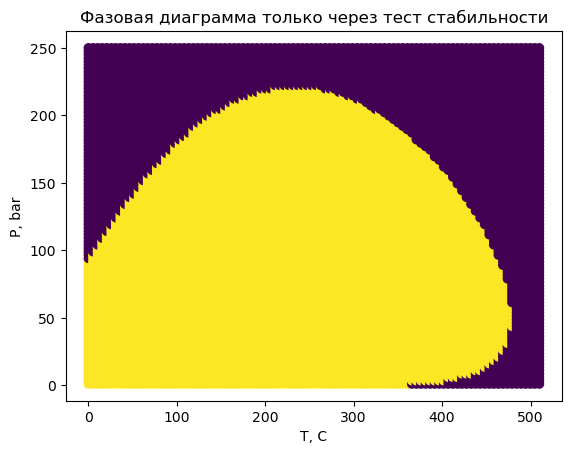

In [53]:
phase_env_from_stab.plot()

### Envelope

In [ ]:
phase_envelope = PhaseDiagramCalculator(comp_KRSNL, 273.15, 550 + 273.15)
phase_envelope.calculate_phase_envelope()

In [ ]:
phase_envelope.plot_phase_diagram()

#### From VBA

In [ ]:
import numpy as np
import logging
from typing import Dict, Optional
from _src.Composition.CompositionV2 import Composition
from _src.PhaseStability.TwoPhaseStabilityTestV3 import TwoPhaseStabilityTest

logger = logging.getLogger(__name__)


class PhaseDiagramCalculator:
    """
    Расчет фазовой диаграммы методом бисекции (как в VBA).
    """
    
    def __init__(self, composition: Composition, T_min: float, T_max: float, dt: float = 5.0):
        self.composition = composition
        self.T_min = T_min
        self.T_max = T_max
        self.dt = dt
        
        self.bubble_points = {'T': [], 'P': []}
        self.dew_points = {'T': [], 'P': []}
    
    def _stability_test(self, P: float, T: float) -> Dict:
        """
        Тест стабильности Michelsen (как в VBA).
        Возвращает: stable, Sv, Sl, K_v, K_l
        """
        stab = TwoPhaseStabilityTest(self.composition, P, T)
        stab.calculate_phase_stability()
        
        return {
            'stable': stab.stable,
            'S_v': stab.S_v,
            'S_l': stab.S_l,
            'K_v': stab.k_values_vapour,
            'K_l': stab.k_values_liquid,
            'K_flash': stab.k_values_for_flash
        }
    
    def _find_saturation_pressure(self, T: float, P_prev: float) -> Optional[Dict]:
        """
        Поиск давления насыщения методом бисекции (как в VBA).
        """
        self.composition.T = T
        
        # Начальные границы
        P_max = 2.0 * P_prev if P_prev > 0 else 300.0
        P_min = 0.0
        P = P_prev if P_prev > 0 else 100.0
        
        # Тест стабильности при текущем P
        stab = self._stability_test(P, T)
        
        if stab['stable']:
            # Система стабильна — нужно найти давление, где она становится нестабильной
            # Идем вниз (bubble) или вверх (dew)
            logger.info(f"T={T-273.15:.1f}°C: Stable at P={P:.2f} bar, searching...")
            
            # Пробуем найти нестабильную область
            for _ in range(20):
                P_test = P * 0.5
                stab_test = self._stability_test(P_test, T)
                
                if not stab_test['stable']:
                    P_max = P
                    P_min = P_test
                    break
                
                P = P_test
            else:
                return None  # Не нашли нестабильную область
        
        # Бисекция
        for _ in range(50):
            if P_max - P_min < 1e-6:
                break
            
            P = (P_max + P_min) / 2.0
            stab = self._stability_test(P, T)
            
            if stab['stable']:
                P_max = P
            else:
                P_min = P
        
        # Определяем тип точки насыщения
        if stab['S_v'] > 1.0 and stab['S_v'] > stab['S_l']:
            # Bubble point
            return {'type': 'bubble', 'P': P, 'S_v': stab['S_v'], 'S_l': stab['S_l']}
        elif stab['S_l'] > 1.0 and stab['S_l'] > stab['S_v']:
            # Dew point
            return {'type': 'dew', 'P': P, 'S_v': stab['S_v'], 'S_l': stab['S_l']}
        else:
            return None
    
    def calculate(self) -> Dict:
        """
        Основной расчет фазовой диаграммы.
        """
        logger.info(f"Starting phase diagram calculation: T=[{self.T_min-273.15:.1f}, {self.T_max-273.15:.1f}]°C")
        
        P_prev = 100.0  # Начальное давление
        
        T = self.T_max
        while T >= self.T_min:
            logger.info(f"\n{'='*60}")
            logger.info(f"T = {T-273.15:.2f}°C")
            
            result = self._find_saturation_pressure(T, P_prev)
            
            if result is not None:
                if result['type'] == 'bubble':
                    self.bubble_points['T'].append(T)
                    self.bubble_points['P'].append(result['P'])
                    logger.info(f"  Bubble point: P = {result['P']:.4f} bar")
                else:
                    self.dew_points['T'].append(T)
                    self.dew_points['P'].append(result['P'])
                    logger.info(f"  Dew point: P = {result['P']:.4f} bar")
                
                P_prev = result['P']
            else:
                logger.info(f"  No saturation point found")
            
            T -= self.dt
        
        return {
            'bubble': self.bubble_points,
            'dew': self.dew_points
        }



In [ ]:
phase_diag_vba = PhaseDiagramCalculator(comp_KRSNL, T_min=280, T_max=500 + 273.15, dt=20)

In [ ]:
phase_diag_vba.calculate()

In [ ]:
import pandas as pd
upp_df = pd.DataFrame.from_dict(phase_diag_vba.bubble_points)
low_df = pd.DataFrame.from_dict(phase_diag_vba.dew_points)

In [ ]:
upp_df

In [ ]:
low_df

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
full_df = pd.concat([upp_df, low_df], ignore_index=True)


In [ ]:
plt.scatter(full_df['T'], full_df['P'])

### CritPoint

In [ ]:
crit_p = CriticalPointCalculator(comp_KRSNL)
crit_p.calculate()

#### Parallel

In [ ]:
crit_p_par = CriticalPointCalculatorParallel(comp_KRSNL)
crit_p_par.calculate()

### Версия Дениса по расчету Pdew - нужно передавать K-факторы отдельно (где я их должен взять :/)

In [ ]:
from _src.PhaseDiagram.SaturationPressure_den_v import DewPointCalculator

In [ ]:
sat_p_den = DewPointCalculator(comp_KRSNL, T=350 + 273.15)

In [ ]:
sat_p_den.calculate()

## Critical Point

In [ ]:
# _src/PVT/CriticalPointCalculatorV1.py
import numpy as np
from _src.Composition.CompositionV2 import Composition
from _src.EOS.BrusilovskiyEOSV2 import BrusilovskiyEOS
from _src.PhaseStability.TwoPhaseStabilityTestV3 import TwoPhaseStabilityTest
from _src.Utils.Errors import StopIterationError

class CriticalPointCalculator:
    """
    Расчет критической точки многокомпонентной смеси методом сканирования (T, P) сетки.
    Использует ваш TwoPhaseStabilityTest для определения перехода двухфазной области в однофазную.
    
    Критерий критической точки:
      - S_v -> 1.0 и S_l -> 1.0 (фазовые фракции стремятся к единице)
      - K-values сходятся к тривиальному решению (K_i -> 1.0)
    """
    def __init__(
        self, 
        composition: Composition, 
        t_range: tuple = None, 
        p_range: tuple = None, 
        t_step: float = 5.0, 
        p_step: float = 1.0, 
        tol_metric: float = 1e-6
    ):
        self.comp = composition
        self.t_step = t_step
        self.p_step = p_step
        self.tol_metric = tol_metric

        # Автоматический расчет диапазонов, если не заданы
        tc_vals = np.array([composition.composition_data['critical_temperature'][c] for c in composition.composition])
        pc_vals = np.array([composition.composition_data['critical_pressure'][c] for c in composition.composition])

        self.t_min, self.t_max = t_range or (tc_vals.min() * 0.8, tc_vals.max() * 1.15)
        self.p_min, self.p_max = p_range or (1.0, pc_vals.max() * 1.3)

        self._best_T = None
        self._best_P = None
        self._best_stab = None
        self._min_metric = float('inf')
        self._history = []

    def calculate(self) -> dict:
        """
        Запускает поиск по сетке (T, P).
        Возвращает словарь с результатами или None, если поиск не дал сходимости.
        """
        t_grid = np.arange(self.t_min, self.t_max, self.t_step)
        p_grid = np.arange(self.p_min, self.p_max, self.p_step)

        for T in t_grid:
            for P in p_grid:
                try:
                    self.comp.T = T
                    stab = TwoPhaseStabilityTest(self.comp, P, T)
                    stab.calculate_phase_stability()

                    # Метрика близости к критической точке
                    s_v = stab.S_v if stab.S_v is not None else 100.0
                    s_l = stab.S_l if stab.S_l is not None else 100.0
                    
                    # Отклонение S от 1.0
                    metric = abs(s_v - 1.0) + abs(s_l - 1.0)

                    # Бонус за сходимость в тривиальное решение (K -> 1)
                    if stab.convergence_trivial_solution_v and stab.convergence_trivial_solution_l:
                        metric *= 0.01

                    if metric < self._min_metric:
                        self._min_metric = metric
                        self._best_T, self._best_P, self._best_stab = T, P, stab

                        # Ранний выход, если достигнута высокая точность
                        if self._min_metric < self.tol_metric:
                            break

                except (StopIterationError, ZeroDivisionError, ValueError, RuntimeError):
                    # Игнорируем точки, где EOS или тест стабильности не сходятся
                    continue
            if self._min_metric < self.tol_metric:
                break

        if self._best_stab is None:
            return None

        return {
            'T_crit': float(self._best_T),
            'P_crit': float(self._best_P),
            'S_v': float(self._best_stab.S_v),
            'S_l': float(self._best_stab.S_l),
            'K_v': self._best_stab.k_values_vapour,
            'K_l': self._best_stab.k_values_liquid,
            'metric': float(self._min_metric),
            'is_trivial_converged': bool(
                self._best_stab.convergence_trivial_solution_v and 
                self._best_stab.convergence_trivial_solution_l
            )
        }

    def refine_with_newton(self, T0: float, P0: float, max_iter: int = 20):
        """
        ЗАГОТОВКА НА БУДУЩЕЕ: уточнение точки методом Ньютона/оптимизации.
        После тестов сетки здесь можно подключить scipy.optimize.root или 
        аналитический расчет производных из BrusilovskiyEOSV2.
        """
        pass  # Реализуем на следующем этапе по вашему запросу

In [ ]:
crit_point_obj = CriticalPointCalculator(composition)

In [ ]:
crit_point_obj.calculate()

### Через параллельный счет

In [ ]:
import numpy as np
from typing import Optional, Dict, Any, Tuple
from joblib import Parallel, delayed
from _src.Composition.CompositionV2 import Composition
from _src.PhaseStability.TwoPhaseStabilityTestV3 import TwoPhaseStabilityTest


def _evaluate_grid_point(composition: Composition, t: float, p: float) -> Optional[Dict[str, Any]]:
    """
    Вычисляет метрику близости к критической точке для заданных (T, P).
    Вынесена на уровень модуля для корректной сериализации в joblib.
    """
    try:
        comp = composition.new_composition(composition.composition, deep_copy=True)
        comp.T = t
        stab = TwoPhaseStabilityTest(comp, p, t)
        stab.calculate_phase_stability()

        s_v = stab.S_v
        s_l = stab.S_l

        if s_v is None or s_l is None:
            return None

        # 1. Базовая метрика: суммарное отклонение фазовых фракций от 1.0
        metric = abs(s_v - 1.0) + abs(s_l - 1.0)

        # 2. Бонус за сходимость в тривиальное решение (K_i -> 1)
        if stab.convergence_trivial_solution_v and stab.convergence_trivial_solution_l:
            metric *= 0.01

        # 3. Штраф за отсутствие сходимости хотя бы одного цикла (v/l)
        conv_v = stab.convergence_v or stab.convergence_trivial_solution_v
        conv_l = stab.convergence_l or stab.convergence_trivial_solution_l
        if not (conv_v and conv_l):
            metric += 10.0

        return {
            'T': float(t) - 273.15,
            'P': float(p),
            'metric': float(metric),
            'S_v': float(s_v),
            'S_l': float(s_l),
            'K_v': stab.k_values_vapour,
            'K_l': stab.k_values_liquid,
            'is_trivial': bool(stab.convergence_trivial_solution_v and stab.convergence_trivial_solution_l),
            'stable': stab.stable
        }
    except Exception:
        # Игнорируем точки, где EOS не сходится, возникает деление на ноль или StopIterationError
        return None




class CriticalPointCalculatorParrallel:
    """
    Расчет критической точки многокомпонентной смеси методом сканирования сетки (T, P).
    Использует joblib для параллельного выполнения независимых расчетов стабильности.
    Автоматически определяет границы поиска по Tc и Pc компонентов, если они не заданы явно.
    """
    def __init__(
        self,
        composition: Composition,
        t_range: Optional[Tuple[float, float]] = None,
        p_range: Optional[Tuple[float, float]] = None,
        t_step: float = 5.0,
        p_step: float = 5.0,
        n_jobs: int = -1,
        backend: str = 'loky'
    ):
        self.composition = composition
        self.t_step = t_step
        self.p_step = p_step
        self.n_jobs = n_jobs
        self.backend = backend

        comp_data = composition.composition_data
        components = tuple(composition.composition.keys())

        # Проверка наличия критических параметров
        if not comp_data.get('critical_temperature') or not comp_data.get('critical_pressure'):
            raise RuntimeError(
                "Необходимо предварительно вызвать composition.evaluate_composition_data(), "
                "чтобы заполнить critical_temperature и critical_pressure."
            )

        # Автоматическая генерация границ
        tc_vals = np.fromiter(
            (comp_data['critical_temperature'][c] for c in components), dtype=np.float64
        )
        pc_vals = np.fromiter(
            (comp_data['critical_pressure'][c] for c in components), dtype=np.float64
        )

        self.t_min, self.t_max = t_range or (float(tc_vals.min() * 0.5), float(tc_vals.max() * 1.5))
        self.p_min, self.p_max = p_range or (1.0, float(pc_vals.max() * 3))

    def calculate(self) -> Optional[Dict[str, Any]]:
        """
        Запускает параллельный поиск по сетке и возвращает параметры точки 
        с минимальной метрикой близости к критическому состоянию.
        """
        # Генерация сетки (с учётом погрешности float для включения верхней границы)
        t_grid = np.arange(self.t_min, self.t_max + self.t_step * 0.5, self.t_step)
        p_grid = np.arange(self.p_min, self.p_max + self.p_step * 0.5, self.p_step)
        points = [(t, p) for t in t_grid for p in p_grid]

        # Параллельное выполнение
        with Parallel(n_jobs=self.n_jobs, backend=self.backend) as parallel:
            results = parallel(
                delayed(_evaluate_grid_point)(self.composition, t, p)
                for t, p in points
            )

        # Фильтрация успешных расчетов
        valid_results = [r for r in results if r is not None]
        if not valid_results:
            return None

        # Выбор точки с наименьшей метрикой
        return min(valid_results, key=lambda x: x['metric'])


In [ ]:
crit_point_obj_par = CriticalPointCalculatorParrallel(comp_KRSNL)
crit_point_obj_par.calculate()

# CCE в параллель - неэффективно

In [ ]:
from _src.Experiments.CCE2 import CCE

In [ ]:
cce = CCE(comp_KRSNL, [500, 400, 390, 370, 360, 350, 340, 330, 320, 310, 300, 290, 280, 270, 250, 240,230,220, 210, 200, 190], 110)

In [ ]:
cce.calculate()

In [ ]:
cce.calculate_parallel()